[G1] 注意力权重分布图已成功保存至: ../results/5_2_1_attention_weights_G1.png


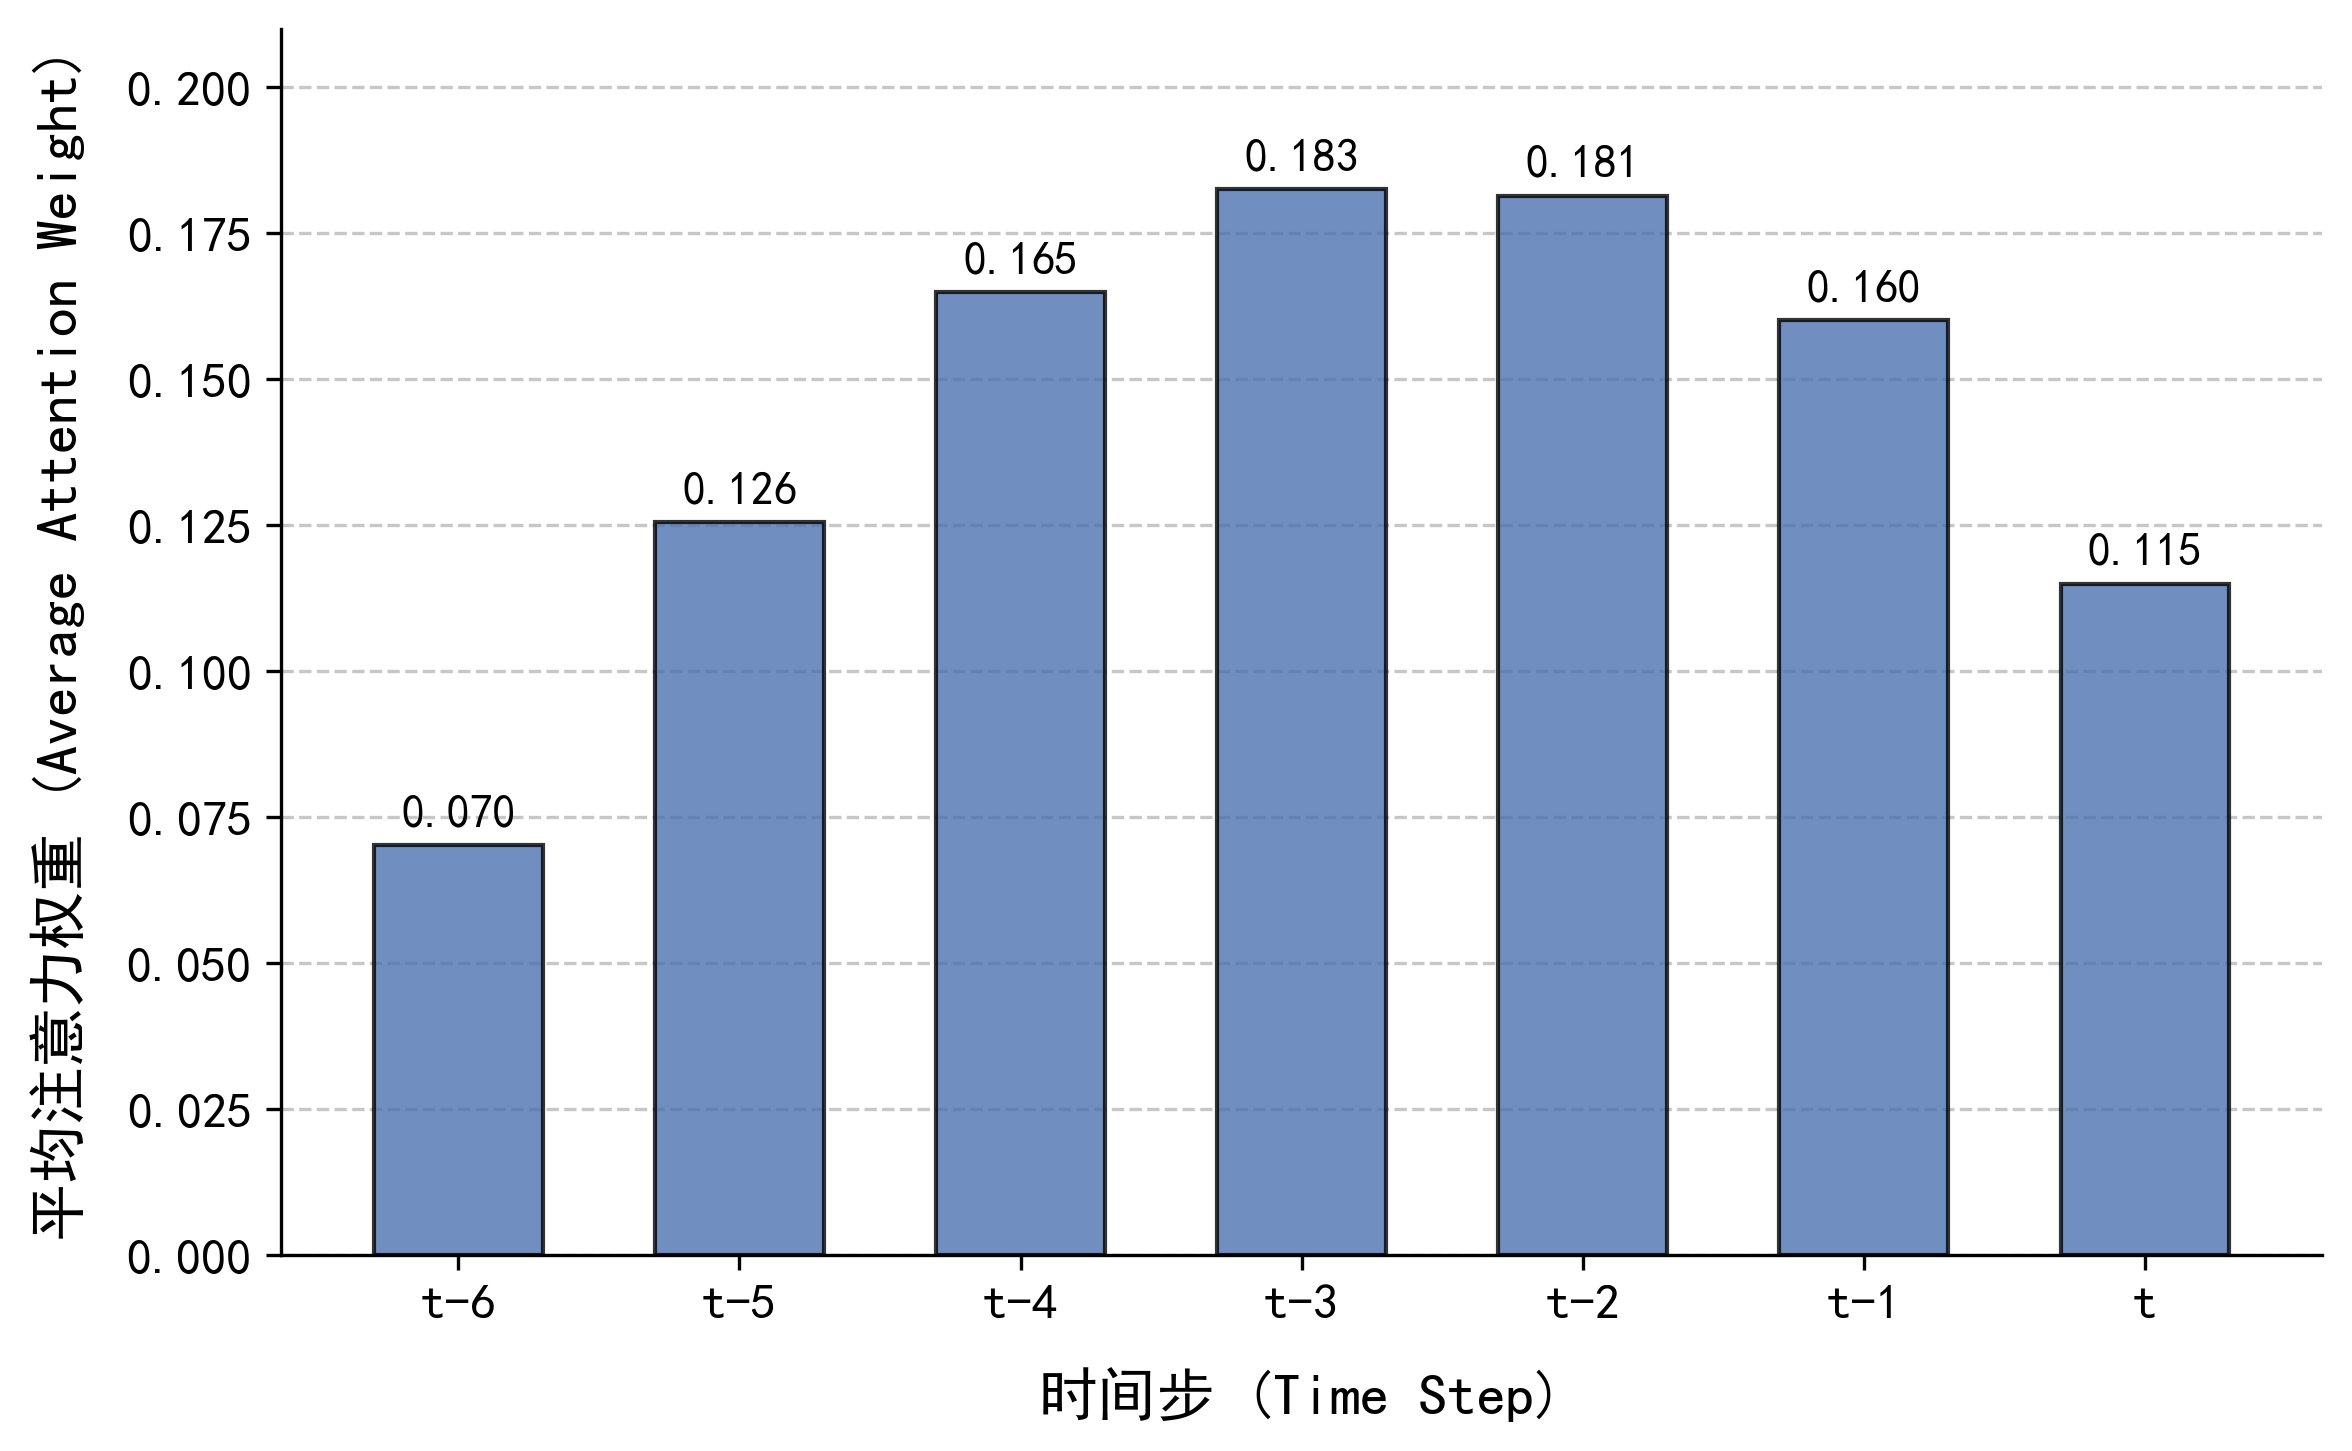

[G2] 注意力权重分布图已成功保存至: ../results/5_2_2_attention_weights_G2.png


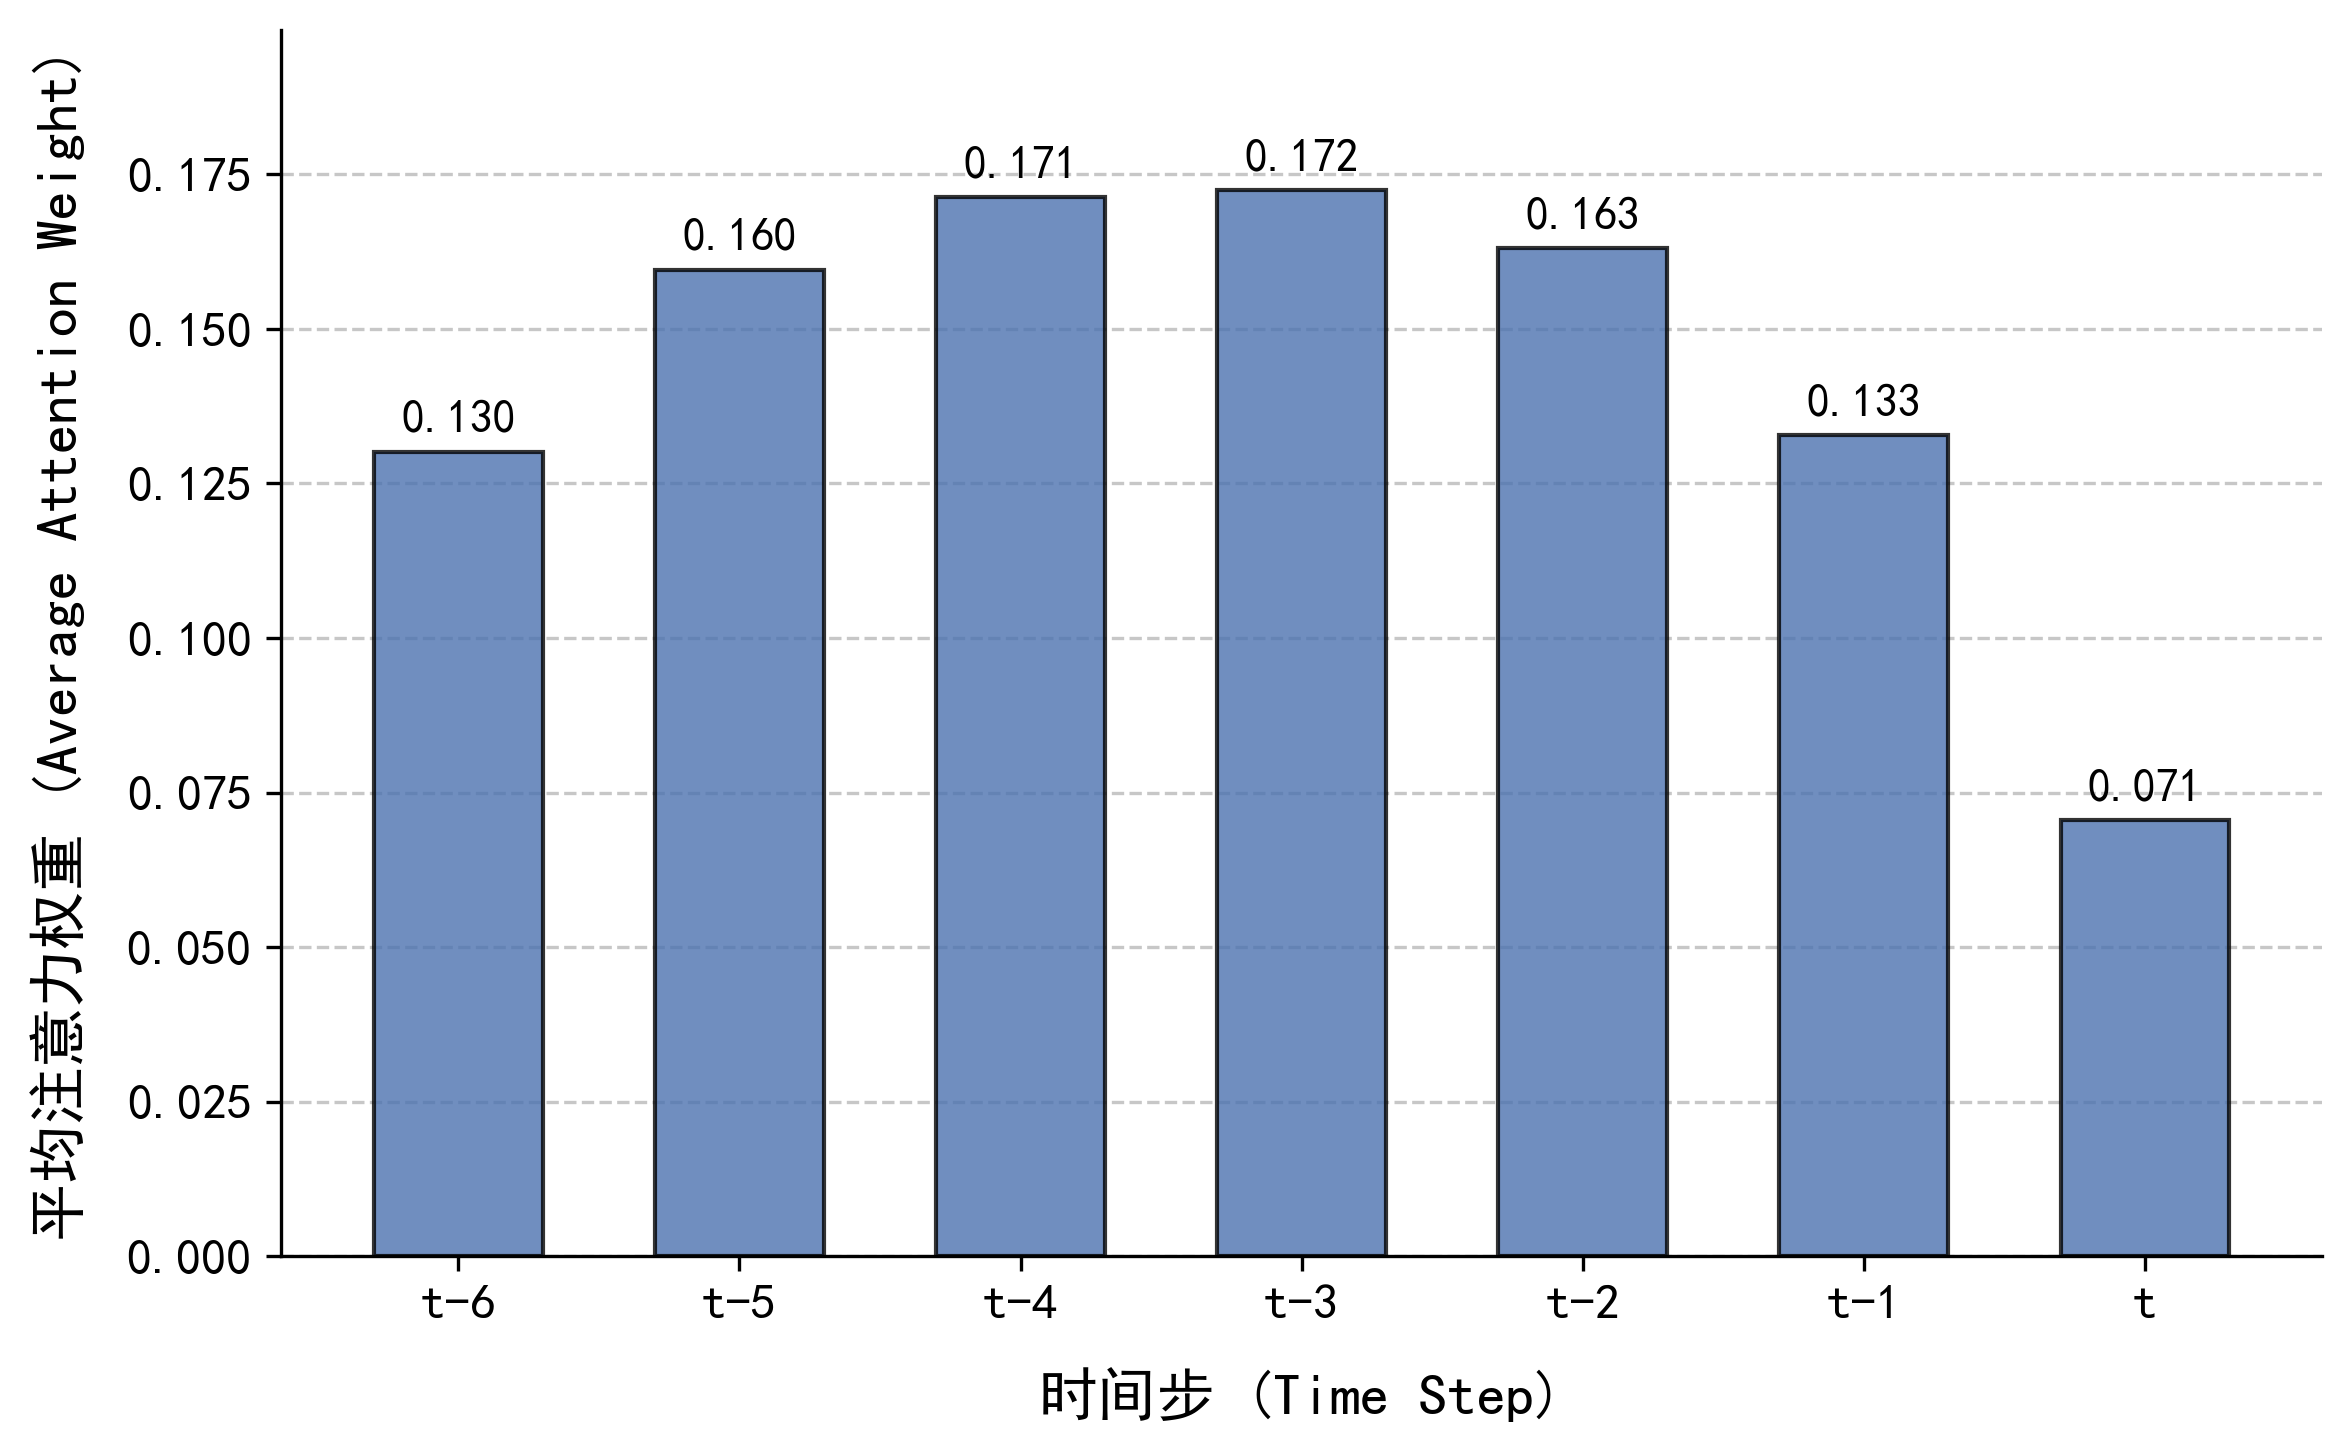

[G3] 注意力权重分布图已成功保存至: ../results/5_2_3_attention_weights_G3.png


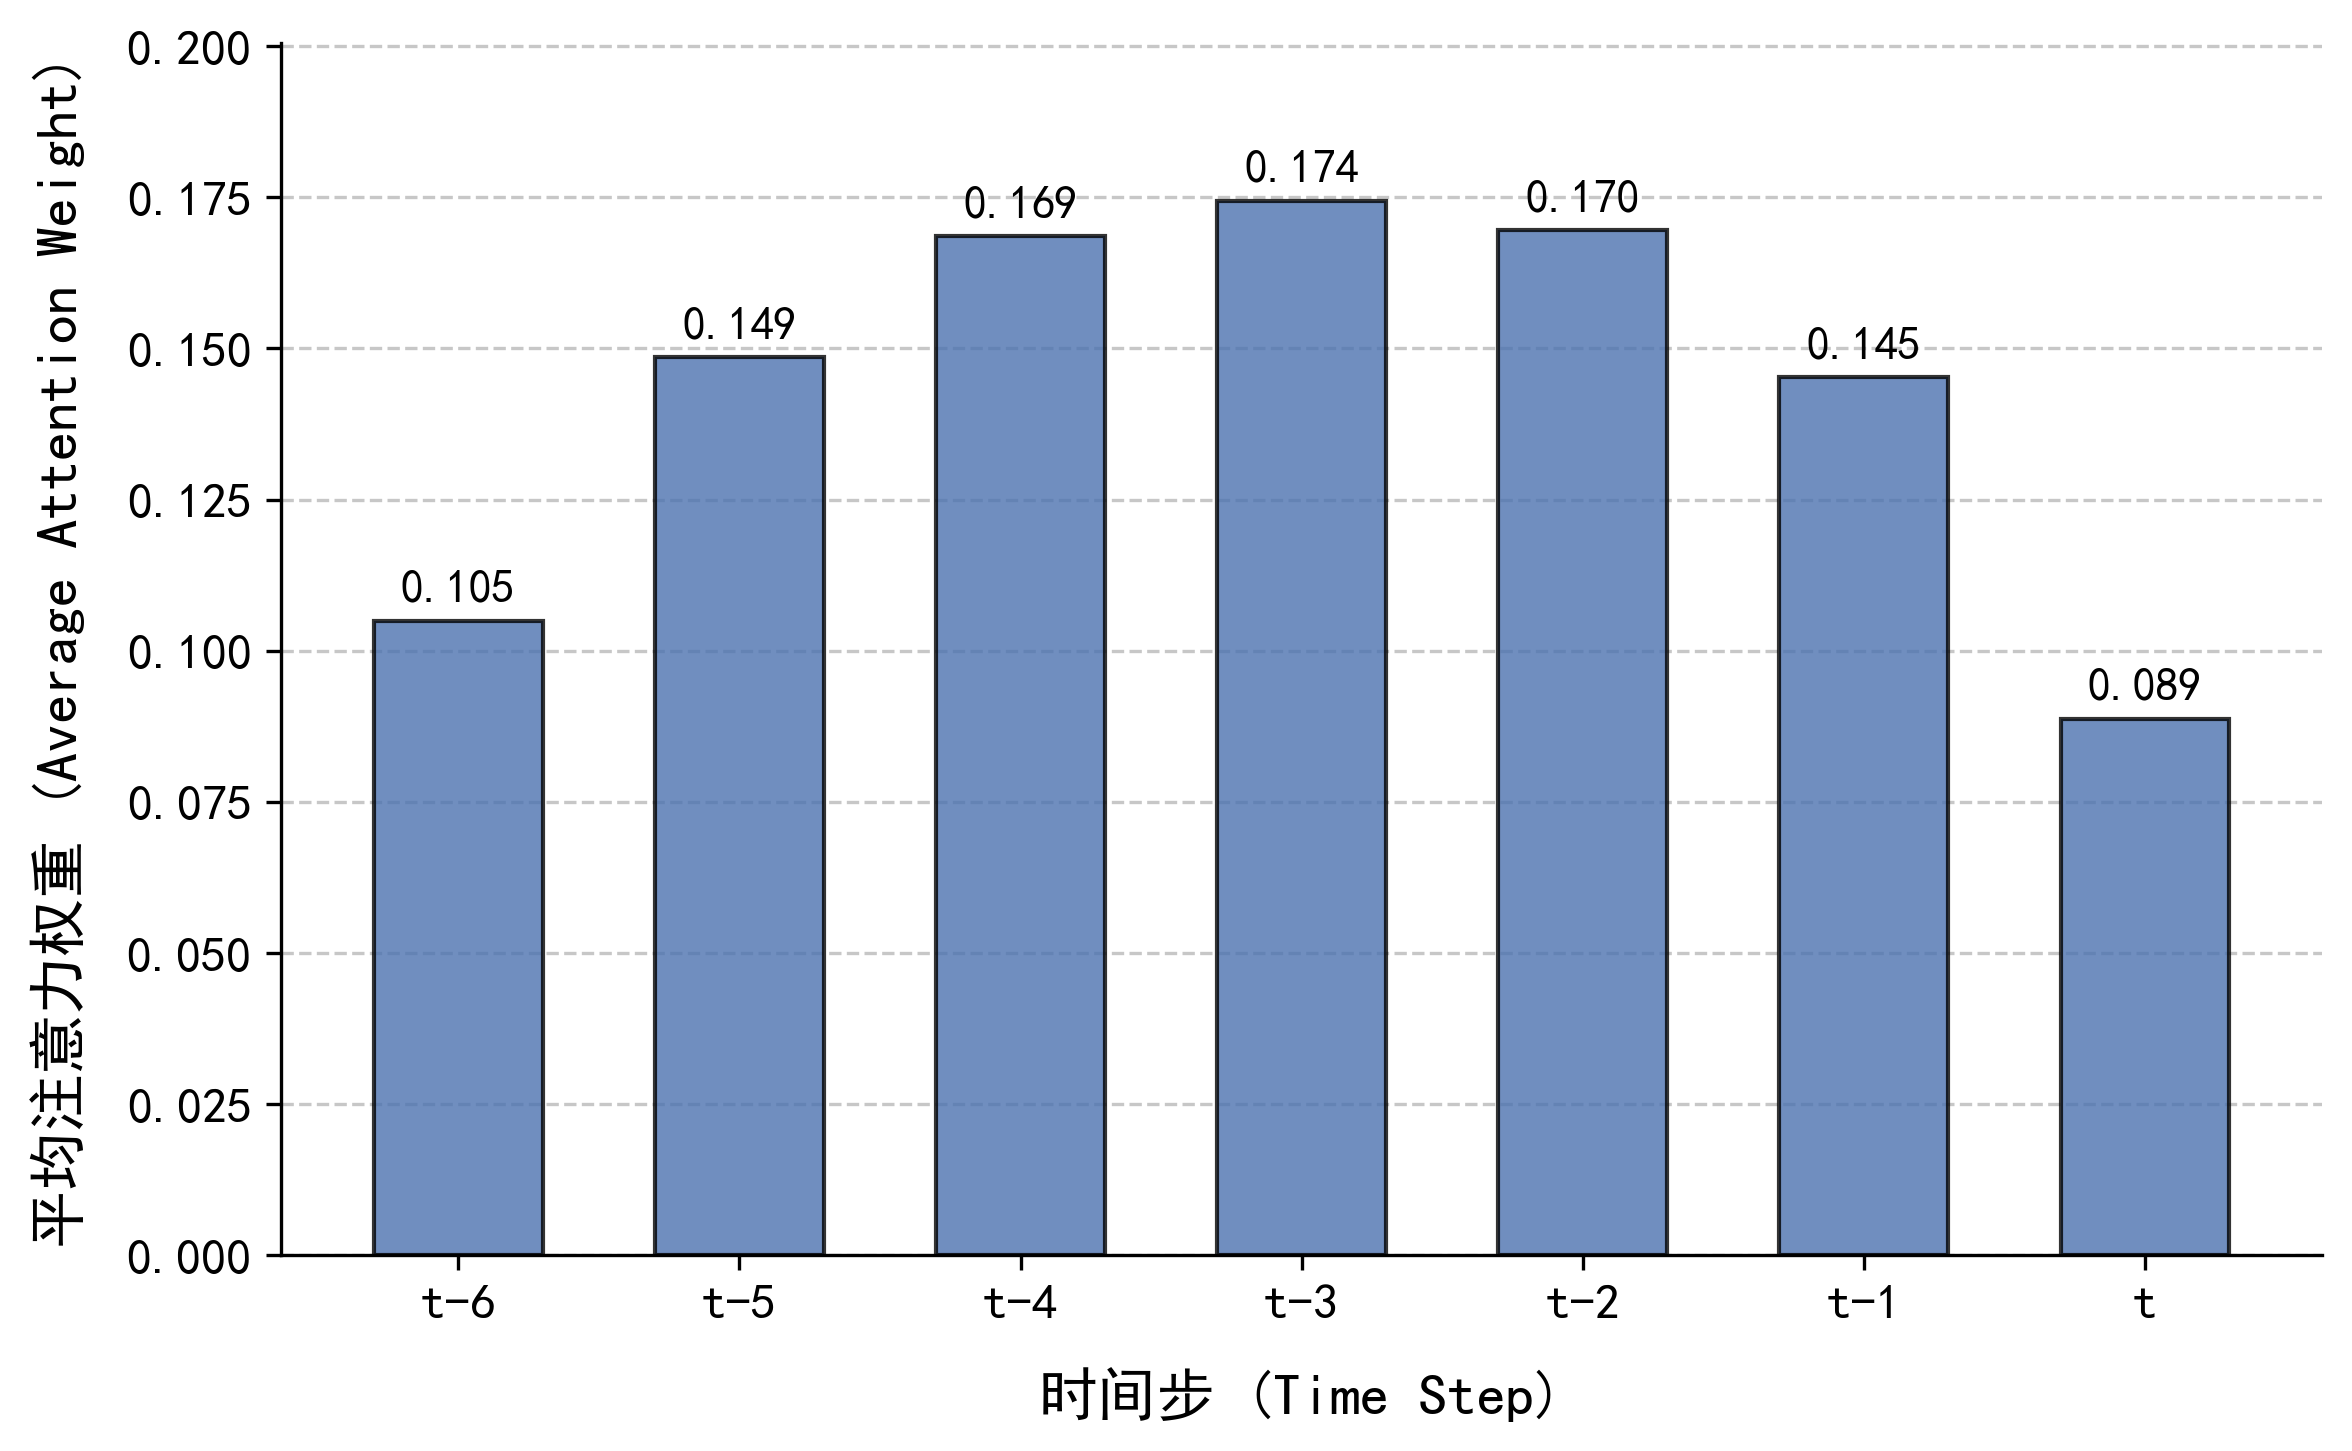

[G3-M] 注意力权重分布图已成功保存至: ../results/5_2_4_attention_weights_G3-M.png


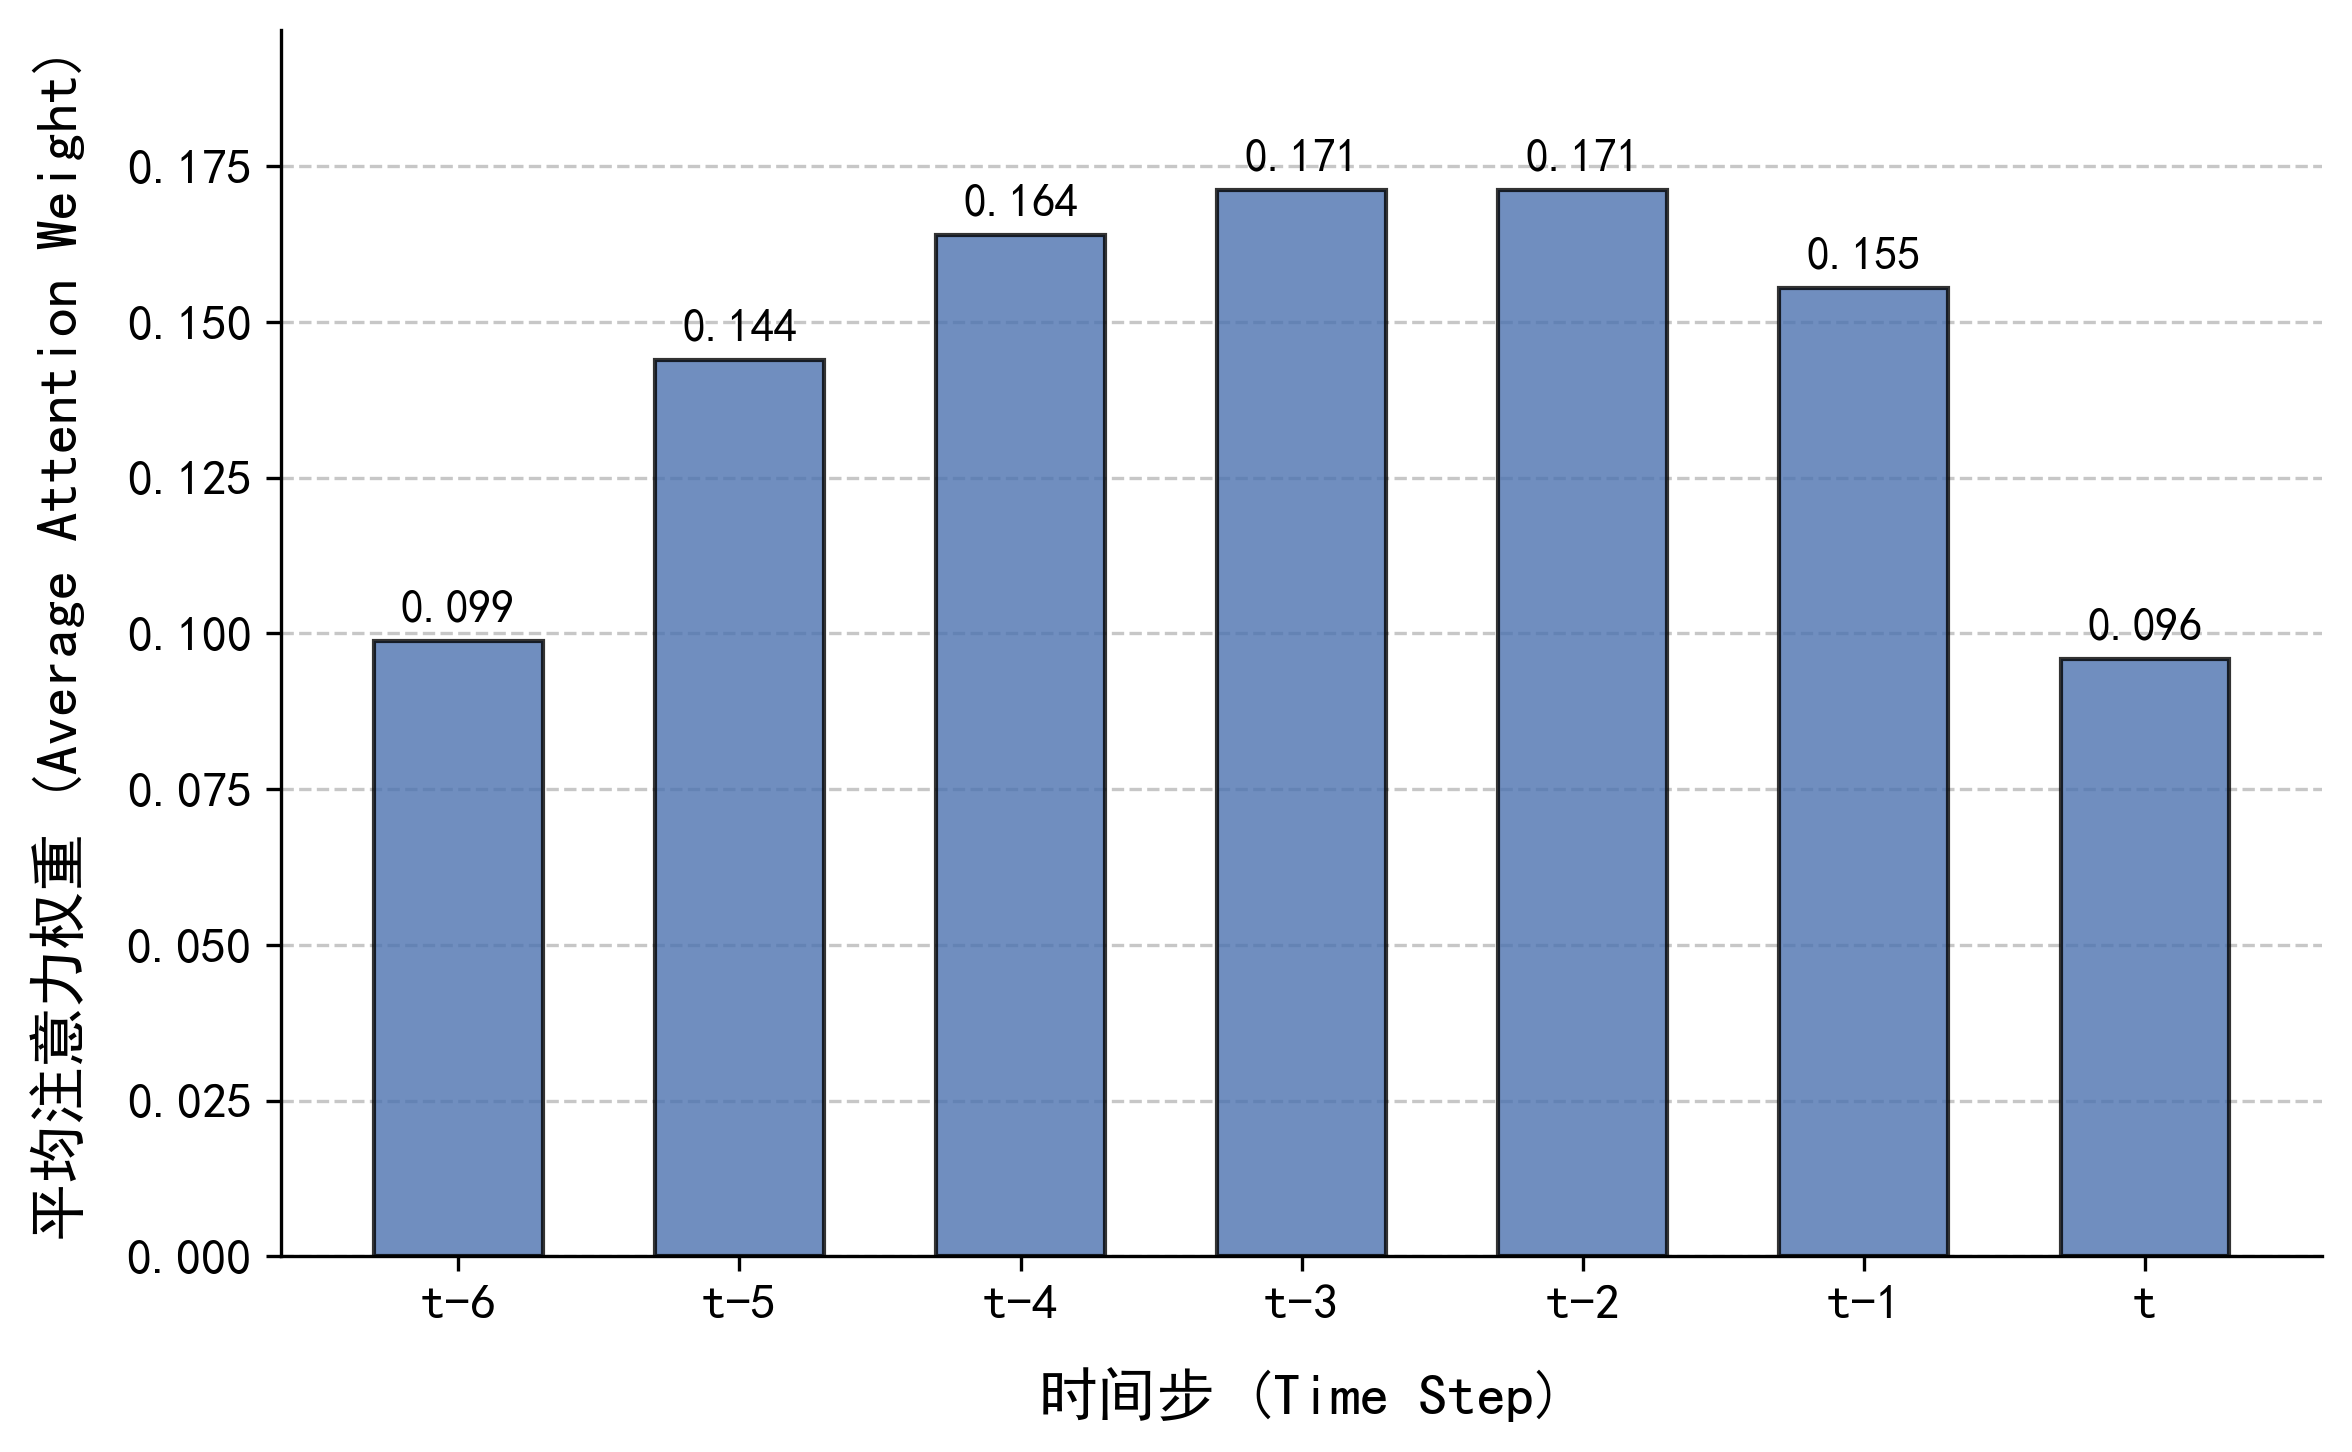


🎉 所有现有组别的 Attention 可视化均已完成！


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# ==========================================
# 1. 字体兼容性与绘图全局设置 (Windows 环境)
# ==========================================
# 设置中文字体为黑体 (SimHei)，并修复负号显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False     

# 设置全局字体大小，方便 Word 中查看
plt.rcParams.update({'font.size': 12})

# ==========================================
# 2. 路径配置与组别设定
# ==========================================
RESULT_DIR = '../results/'
# 对应提取的四个特征组
groups = ['G1', 'G2', 'G3', 'G3-M']

# X轴的标签，代表过去的 7 天 (t-6 到 t)
time_steps_labels = ['t-6', 't-5', 't-4', 't-3', 't-2', 't-1', 't']

# ==========================================
# 3. 绘图主逻辑
# ==========================================
for i, group in enumerate(groups):
    file_path = os.path.join(RESULT_DIR, f'attention_weights_{group}.npy')
    
    # 检查文件是否存在（兼容 DEBUG_MODE 仅运行 G1 的情况）
    if not os.path.exists(file_path):
        print(f"⚠️ 未找到 {group} 的权重文件，跳过绘图: {file_path}")
        continue
        
    # 加载 Attention 权重矩阵 Shape: (Test_Size, 7)
    attn_matrix = np.load(file_path)
    
    # 计算所有测试集样本在每个时间步上的平均注意力权重
    mean_attn_weights = np.mean(attn_matrix, axis=0)
    
    # 开始绘图
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # 绘制柱状图，使用温和的蓝色
    bars = ax.bar(time_steps_labels, mean_attn_weights, color='#4C72B0', edgecolor='black', alpha=0.8, width=0.6)
    
    # 严禁包含原生标题 (去掉 plt.title)
    
    # 轴标签中文化及符号化
    ax.set_xlabel('时间步 (Time Step)', fontsize=14, fontweight='bold', labelpad=10)
    ax.set_ylabel('平均注意力权重 (Average Attention Weight)', fontsize=14, fontweight='bold', labelpad=10)
    
    # 设置Y轴范围略微高于最大值，留出空间
    ax.set_ylim(0, max(mean_attn_weights) * 1.15)
    
    # 在柱子上方添加具体的数值标签，方便论文中引用确切数据
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 垂直偏移3个像素
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11)
        
    # 添加Y轴的水平网格线，使图表更加专业
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True) # 保证网格线在柱子下方
    
    # 去除顶部和右侧的边框线
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 紧凑布局
    plt.tight_layout()
    
    # 保存格式要求：指定至第五章图表命名规则 (例如 图5-2, 5-3...)，dpi=300
    # 这里以 5_2_xxx 为例，按顺序递增
    save_filename = f'5_2_{i+1}_attention_weights_{group}.png'
    save_path = os.path.join(RESULT_DIR, save_filename)
    
    plt.savefig(save_path, dpi=300, format='png', bbox_inches='tight')
    print(f"[{group}] 注意力权重分布图已成功保存至: {save_path}")
    
    # 同时显示图表
    plt.show()

print("\n🎉 所有现有组别的 Attention 可视化均已完成！")